# Stock Market Trend Analysis: Volatility and Risk

This notebook measures daily and annualized volatility, 30-day rolling annualized volatility, and a descriptive risk-versus-return comparison for AAPL, MSFT, GOOGL, AMZN, and NVDA.

Annualized volatility uses the standard assumption of 252 trading days per year. The analysis does not calculate Sharpe ratio, correlation, beta, alpha, or investment signals.

## Objective

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "data").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.risk_analysis import (
    FIGURES_DIR,
    ROLLING_WINDOW,
    TRADING_DAYS_PER_YEAR,
    TICKERS,
    build_risk_summary,
    independent_volatility_sanity_check,
    plot_annualized_volatility,
    plot_rolling_volatility,
    plot_risk_vs_return,
    save_risk_summary,
)

risk_data, risk_summary = build_risk_summary()
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
print("Loaded Phase 4 return data and calculated Phase 5 risk measures.")

Loaded Phase 4 return data and calculated Phase 5 risk measures.


## Daily and annualized volatility

In [2]:
display(risk_summary.round(6))
print(f"Daily volatility is annualized using sqrt({TRADING_DAYS_PER_YEAR}) and a {ROLLING_WINDOW}-trading-day rolling window.")

,Daily Volatility,Daily Volatility (%),Annualized Volatility,Annualized Volatility (%),Minimum Daily Return,Maximum Daily Return,Mean Daily Return,Total Return
Stock,,,,,,,,
AAPL,0.017666,1.766597,0.280439,28.043854,-0.092456,0.153289,0.000718,1.024418
MSFT,0.017731,1.773104,0.281472,28.147154,-0.099931,0.155067,0.000571,0.681602
GOOGL,0.020235,2.023537,0.321227,32.122656,-0.095094,0.102244,0.000935,1.500913
AMZN,0.022924,2.292390,0.363906,36.390567,-0.140494,0.153206,0.000632,0.592306
NVDA,0.032718,3.271850,0.519390,51.939001,-0.169682,0.243696,0.002464,10.286215


Daily volatility is annualized using sqrt(252) and a 30-trading-day rolling window.


## Independent volatility sanity check

In [3]:
maximum_difference = independent_volatility_sanity_check(risk_data, risk_summary)
print(f"Maximum annualized-volatility difference: {maximum_difference:.3e}")
print("Volatility sanity check: PASS")
_ = save_risk_summary(risk_summary)
print("Risk summary saved.")

Maximum annualized-volatility difference: 0.000e+00
Volatility sanity check: PASS
Risk summary saved.


## Annualized volatility comparison

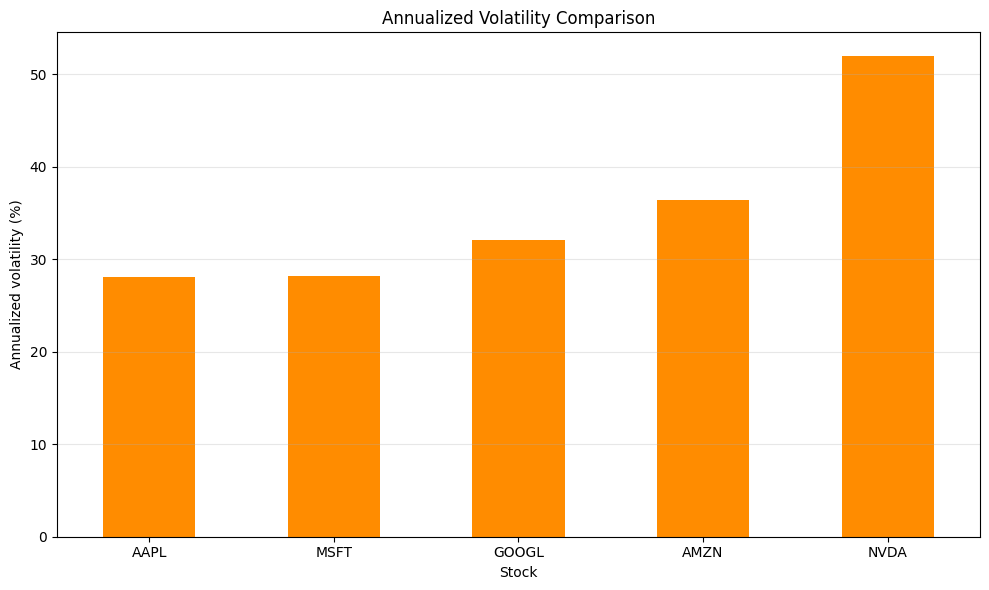

In [4]:
fig = plot_annualized_volatility(risk_summary, FIGURES_DIR / "risk_annualized_volatility.png")
display(fig)
plt.close(fig)

## 30-day rolling annualized volatility

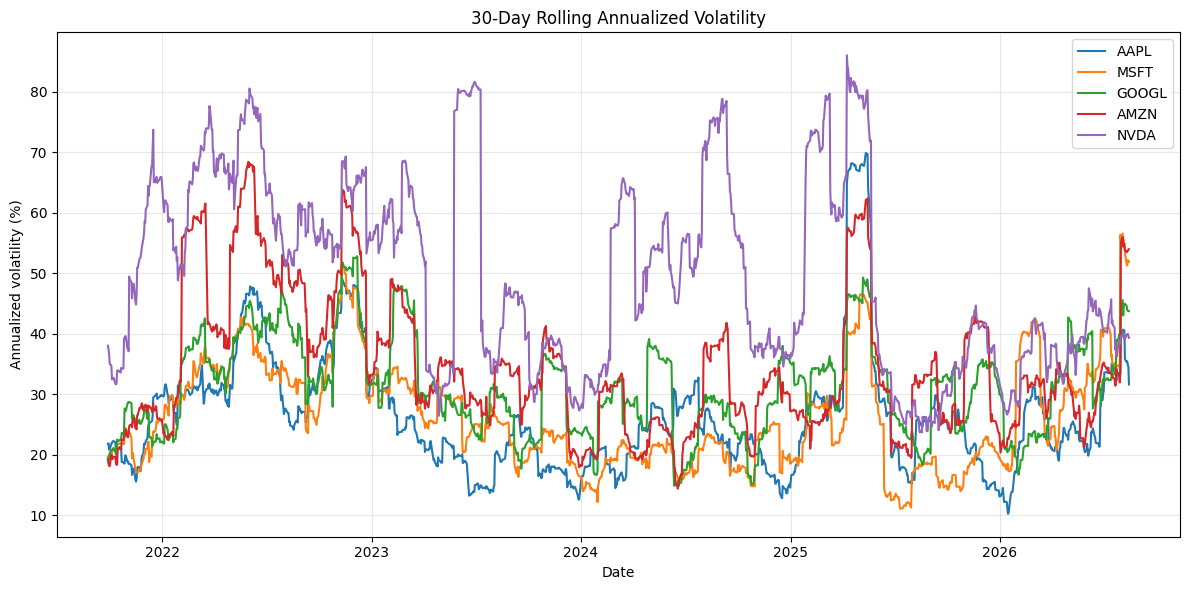

In [5]:
fig = plot_rolling_volatility(risk_data, FIGURES_DIR / "risk_rolling_volatility.png")
display(fig)
plt.close(fig)

## Risk versus performance

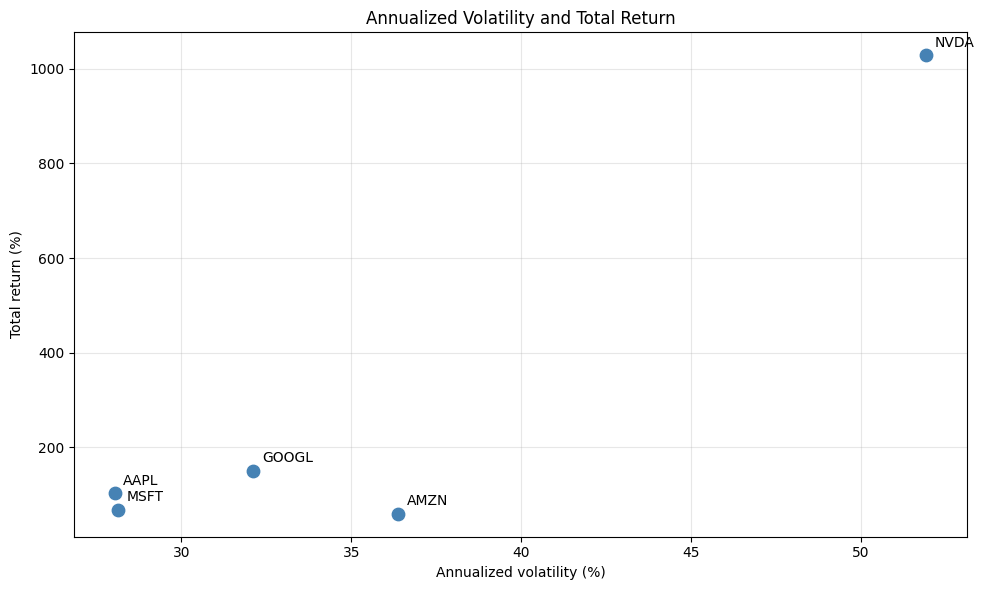

In [6]:
fig = plot_risk_vs_return(risk_summary, FIGURES_DIR / "risk_vs_return.png")
display(fig)
plt.close(fig)

## Key Observations

The following observations are generated directly from the calculated risk and performance metrics. They are descriptive historical observations only, not investment recommendations.

In [7]:
highest_volatility = risk_summary["Annualized Volatility (%)"].idxmax()
lowest_volatility = risk_summary["Annualized Volatility (%)"].idxmin()
highest_total_return = risk_summary["Total Return"].idxmax()
highest_risk_return = risk_summary.loc[highest_volatility, "Total Return"]
print(f"Highest annualized volatility: {highest_volatility}")
print(f"Lowest annualized volatility: {lowest_volatility}")
print(f"Highest total return in this comparison: {highest_total_return}")
print(f"The stock with the highest volatility had a total return of {highest_risk_return:.2%}.")
print("These observations describe historical data and are not investment recommendations.")

Highest annualized volatility: NVDA
Lowest annualized volatility: AAPL
Highest total return in this comparison: NVDA
The stock with the highest volatility had a total return of 1028.62%.
These observations describe historical data and are not investment recommendations.
